# COPER latent embeddings — visualization

Loads **exported** checkpoints (see `utils/export_coper_checkpoint.py`) from `code/COPER`, runs the network up to the **last latent after LayerNorm** (64-D by default), then plots **PCA**, **UMAP**, and optional **t-SNE** colored by mortality label.

**Prerequisite:** export bundles from `notebooks/compare_mortality_mimic3.ipynb` or manually, e.g.
```bash
.venv-coper/bin/python utils/export_coper_checkpoint.py \
  --repo /path/to/code/COPER \
  --ckpt /path/to/COPER-mimic-F-1_D0.5_S1.ckpt \
  --out-dir artifacts --name coper_1node_drop0.5_s1 \
  --drop 0.5 --random-seed 1
```

For a **2-NODE** checkpoint, use the `_N2.ckpt` file and add `--second-node` to the export command.

Install extras if needed: `pip install umap-learn scikit-learn`

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

BENCH = Path("/home/charlesv/Desktop/StatisitcalGenetics/code/COPER").resolve()
if str(BENCH) not in sys.path:
    sys.path.insert(0, str(BENCH))

from utils.coper_embed import latent_before_classifier, latent_grid
from utils.embedding_data_utils import collect_latents, load_xy_split, tensors_to_loader
from utils.load_coper_bundle import load_coper_from_bundle
from utils.viz_utils import run_viz

/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ---- Paths: bundles + repo + data ----
ROOT = Path("/home/charlesv/Desktop/StatisitcalGenetics")
MORTALITY_PICKLE = ROOT / "MIMIC" / "mimic3-benchmarks" / "data" / "mortality_for_coper.data"

REPO = ROOT / "code" / "COPER"
RESULTS_ROOT = BENCH / "results"
ARTIFACTS = BENCH / "artifacts"

# Names match notebooks/compare_mortality_mimic3.ipynb export step (adjust if you changed them)
BUNDLE_1NODE = ARTIFACTS / "coper_1node_drop0.5_s1.pt"
BUNDLE_2NODE = ARTIFACTS / "coper_2node_drop0.5_s1.pt"

# Prediction dumps written by utils/run_exp.py / utils.evaluate(_uq)
PRED_1NODE_OG = RESULTS_ROOT / "Predictions_COPER-Test-OG-mimic--1-1-0.5.npz"
PRED_1NODE_G = RESULTS_ROOT / "Predictions_COPER-Test-G-mimic--1-1-0.5.npz"
PRED_2NODE_OG = RESULTS_ROOT / "Predictions_COPER-Test-OG-mimic--1-1-0.5_2NODE.npz"
PRED_2NODE_G = RESULTS_ROOT / "Predictions_COPER-Test-G-mimic--1-1-0.5_2NODE.npz"

SPLIT = "val"  # "val" | "test" | "train"
MAX_SAMPLES = 2000  # cap for speed; set None for full split
BATCH_SIZE = 64
RANDOM_STATE = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("DEVICE", DEVICE)

DEVICE cuda


COPER_1NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_1ode_1epoch.png


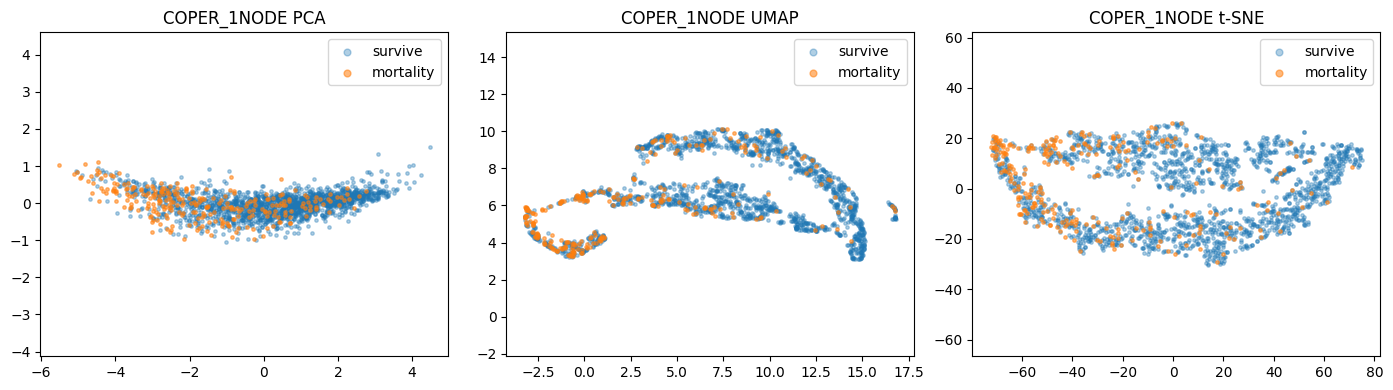

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_1NODE_val_n2000.npz + meta json
COPER_2NODE Z (2000, 64) y (2000,) pos_rate 0.13750000298023224


/home/charlesv/Desktop/StatisitcalGenetics/code/COPER/.venv-coper/lib64/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Saved figure /home/charlesv/Desktop/StatisitcalGenetics/pictures/coper_2node_1epoch.png


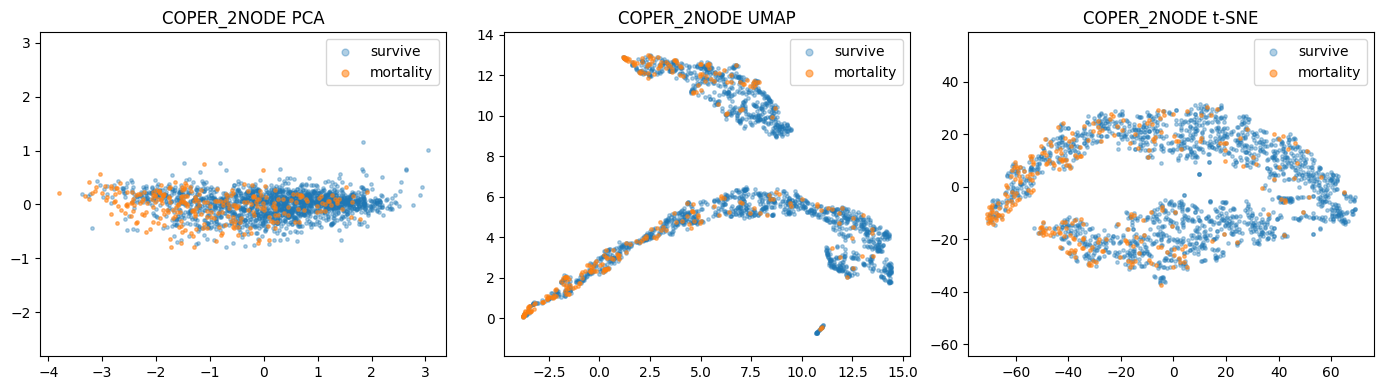

Saved /home/charlesv/Desktop/StatisitcalGenetics/code/COPER/artifacts/latents_COPER_2NODE_val_n2000.npz + meta json


In [3]:
assert MORTALITY_PICKLE.is_file(), MORTALITY_PICKLE
ARTIFACTS.mkdir(parents=True, exist_ok=True)
# Slides / repo root: embedding comparison figures (PCA | UMAP | t-SNE)
PICTURES = ROOT / "pictures"
PICTURES.mkdir(parents=True, exist_ok=True)

viz_1node = run_viz(
    bundle_path=BUNDLE_1NODE,
    repo_root=REPO,
    label="COPER_1NODE",
    device=DEVICE,
    mortality_pickle=MORTALITY_PICKLE,
    split=SPLIT,
    max_samples=MAX_SAMPLES,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE,
    artifacts_dir=ARTIFACTS,
    load_coper_from_bundle=load_coper_from_bundle,
    load_xy_split=load_xy_split,
    tensors_to_loader=lambda X_np, y_np, max_samples, batch_size: tensors_to_loader(
        X_np, y_np, max_samples, batch_size, RANDOM_STATE, DEVICE
    ),
    collect_latents=lambda model, loader: collect_latents(model, loader, latent_before_classifier),
    save_figure_path=PICTURES / "coper_1ode_1epoch.png",
)

viz_2node = run_viz(
    bundle_path=BUNDLE_2NODE,
    repo_root=REPO,
    label="COPER_2NODE",
    device=DEVICE,
    mortality_pickle=MORTALITY_PICKLE,
    split=SPLIT,
    max_samples=MAX_SAMPLES,
    batch_size=BATCH_SIZE,
    random_state=RANDOM_STATE,
    artifacts_dir=ARTIFACTS,
    load_coper_from_bundle=load_coper_from_bundle,
    load_xy_split=load_xy_split,
    tensors_to_loader=lambda X_np, y_np, max_samples, batch_size: tensors_to_loader(
        X_np, y_np, max_samples, batch_size, RANDOM_STATE, DEVICE
    ),
    collect_latents=lambda model, loader: collect_latents(model, loader, latent_before_classifier),
    save_figure_path=PICTURES / "coper_2node_1epoch.png",
)


In [4]:
# ---- Model metadata + parameter count + convergence/runtime summary ----

def _bundle_stats(bundle_path: Path, label: str):
    if not bundle_path.is_file():
        return None
    raw = torch.load(bundle_path, map_location="cpu")
    if isinstance(raw, dict) and "model_state_dict" in raw:
        state = raw["model_state_dict"]
        meta = raw.get("meta", {})
    else:
        state = raw if isinstance(raw, dict) else {}
        meta = {}

    n_params = int(sum(v.numel() for v in state.values())) if isinstance(state, dict) else np.nan
    h = meta.get("hyperparams", {})
    return {
        "model": label,
        "bundle": str(bundle_path),
        "n_params": n_params,
        "fold": h.get("fold"),
        "drop": h.get("drop"),
        "random_seed": h.get("random_seed"),
        "num_latents": h.get("num_latents"),
        "latent_dim": h.get("latent_dim"),
        "rec_layers": h.get("rec_layers"),
        "units": h.get("units"),
        "emb_dim": h.get("emb_dim"),
        "second_node": h.get("second_node"),
    }


bundle_summary = pd.DataFrame([
    x for x in [
        _bundle_stats(BUNDLE_1NODE, "COPER_1NODE"),
        _bundle_stats(BUNDLE_2NODE, "COPER_2NODE"),
    ] if x is not None
])

if not bundle_summary.empty:
    print("Model hyperparameters + number of parameters")
    display(bundle_summary)

# Runtime / convergence proxy from benchmark table (generated by compare notebook)
raw_csv = RESULTS_ROOT / "tables" / "mimic3_repo_comparison_raw.csv"
if raw_csv.is_file():
    run_df = pd.read_csv(raw_csv)
    conv = run_df[[
        "arch_id", "seed", "drop", "runtime_sec",
        "test_og_auroc", "test_og_auprc", "test_g_auroc", "test_g_auprc"
    ]].copy()
    conv["runtime_min"] = conv["runtime_sec"] / 60.0
    print("Convergence/runtime and prediction metrics from latest benchmark run")
    display(conv.sort_values(["arch_id", "seed", "drop"]))
else:
    print(f"No benchmark table found at {raw_csv}. Run compare notebook first.")

Model hyperparameters + number of parameters


,model,bundle,n_params,fold,drop,random_seed,num_latents,latent_dim,rec_layers,units,emb_dim,second_node
0,COPER_1NODE,/home/charlesv/Desktop/StatisitcalGenetics/cod...,223233,-1,0.5,1,48,64,3,128,32,False
1,COPER_2NODE,/home/charlesv/Desktop/StatisitcalGenetics/cod...,289345,-1,0.5,1,48,64,3,128,32,True


Convergence/runtime and prediction metrics from latest benchmark run


,arch_id,seed,drop,runtime_sec,test_og_auroc,test_og_auprc,test_g_auroc,test_g_auprc,runtime_min
0,coper_1node,1,0.5,171.443134,0.7779,0.3306,0.7765,0.3304,2.857386
1,coper_2node,1,0.5,353.688409,0.7611,0.3098,0.7678,0.3195,5.894807


## Prediction-level comparison from saved `.npz`

This section reloads raw prediction dumps produced during training (`results/Predictions_*.npz`) and compares 1-NODE vs 2-NODE on the same patients.

It reports:
- AUROC / AUPRC / Brier score from saved probabilities
- per-case agreement where one model is correct and the other is wrong
- examples where one model strongly out-scores the other

In [5]:
def _best_threshold_gmean(y_true, y_prob):
    fpr, tpr, thr = roc_curve(y_true, y_prob)
    g = np.sqrt(tpr * (1.0 - fpr))
    i = int(np.nanargmax(g))
    return float(thr[i]), float(g[i])


def load_pred_npz(path: Path):
    if not path.is_file():
        raise FileNotFoundError(path)
    with np.load(path, allow_pickle=True) as d:
        keys = set(d.files)

        # Preferred explicit format
        if {"y_true", "pred_prob"}.issubset(keys):
            y_true = np.asarray(d["y_true"]).reshape(-1).astype(int)
            y_prob = np.asarray(d["pred_prob"]).reshape(-1)
            return y_true, y_prob

        # Backward format seen in current runs: only probabilities in arr_0
        # Recover labels from mortality pickle test split.
        if "arr_0" in keys:
            y_prob = np.asarray(d["arr_0"]).reshape(-1)
            _, y_test = load_xy_split(MORTALITY_PICKLE, "test")
            y_true = np.asarray(y_test).reshape(-1).astype(int)
            if y_true.shape[0] != y_prob.shape[0]:
                raise ValueError(
                    f"Length mismatch for {path.name}: y_true={y_true.shape[0]} vs y_prob={y_prob.shape[0]}"
                )
            return y_true, y_prob

    raise KeyError(f"Unsupported prediction npz format in {path}")


def summarize_preds(tag: str, y_true, y_prob):
    thr, gmax = _best_threshold_gmean(y_true, y_prob)
    y_hat = (y_prob >= thr).astype(int)
    return {
        "tag": tag,
        "n": int(y_true.size),
        "pos_rate": float(y_true.mean()),
        "auroc": float(roc_auc_score(y_true, y_prob)),
        "auprc": float(average_precision_score(y_true, y_prob)),
        "brier": float(brier_score_loss(y_true, y_prob)),
        "best_thr_gmean": thr,
        "best_gmean": gmax,
        "acc_at_best_thr": float((y_hat == y_true).mean()),
    }


def compare_casewise(name_a, y_true_a, p_a, name_b, y_true_b, p_b):
    assert np.array_equal(y_true_a, y_true_b), "Prediction files are not aligned on y_true"
    y = y_true_a

    thr_a, _ = _best_threshold_gmean(y, p_a)
    thr_b, _ = _best_threshold_gmean(y, p_b)
    h_a = (p_a >= thr_a).astype(int)
    h_b = (p_b >= thr_b).astype(int)

    a_correct = h_a == y
    b_correct = h_b == y

    a_only = np.where(a_correct & ~b_correct)[0]
    b_only = np.where(b_correct & ~a_correct)[0]

    print(f"{name_a} only-correct cases: {a_only.size}")
    print(f"{name_b} only-correct cases: {b_only.size}")

    # Big confidence gaps (not necessarily correctness): useful to inspect opposite behavior.
    gap = p_a - p_b
    top_a = np.argsort(-gap)[:10]
    top_b = np.argsort(gap)[:10]

    df_a = pd.DataFrame({
        "idx": top_a,
        "y_true": y[top_a],
        f"{name_a}_prob": p_a[top_a],
        f"{name_b}_prob": p_b[top_a],
        "prob_gap_a_minus_b": gap[top_a],
        f"{name_a}_pred": h_a[top_a],
        f"{name_b}_pred": h_b[top_a],
    })
    df_b = pd.DataFrame({
        "idx": top_b,
        "y_true": y[top_b],
        f"{name_a}_prob": p_a[top_b],
        f"{name_b}_prob": p_b[top_b],
        "prob_gap_a_minus_b": gap[top_b],
        f"{name_a}_pred": h_a[top_b],
        f"{name_b}_pred": h_b[top_b],
    })
    return {
        "a_only_idx": a_only,
        "b_only_idx": b_only,
        "a_only_df": pd.DataFrame({"idx": a_only}),
        "b_only_df": pd.DataFrame({"idx": b_only}),
        "top_a_gap_df": df_a,
        "top_b_gap_df": df_b,
    }


# ---- Load and compare OG predictions ----
y_1_og, p_1_og = load_pred_npz(PRED_1NODE_OG)
y_2_og, p_2_og = load_pred_npz(PRED_2NODE_OG)

metrics_og = pd.DataFrame([
    summarize_preds("1NODE_OG", y_1_og, p_1_og),
    summarize_preds("2NODE_OG", y_2_og, p_2_og),
])
display(metrics_og)

og_cases = compare_casewise("1NODE", y_1_og, p_1_og, "2NODE", y_2_og, p_2_og)
print("\nTop cases where 1NODE >> 2NODE (probability gap):")
display(og_cases["top_a_gap_df"])
print("\nTop cases where 2NODE >> 1NODE (probability gap):")
display(og_cases["top_b_gap_df"])

# ---- Load and compare G predictions ----
y_1_g, p_1_g = load_pred_npz(PRED_1NODE_G)
y_2_g, p_2_g = load_pred_npz(PRED_2NODE_G)

metrics_g = pd.DataFrame([
    summarize_preds("1NODE_G", y_1_g, p_1_g),
    summarize_preds("2NODE_G", y_2_g, p_2_g),
])
display(metrics_g)

g_cases = compare_casewise("1NODE", y_1_g, p_1_g, "2NODE", y_2_g, p_2_g)
print("\nTop cases where 1NODE >> 2NODE (probability gap):")
display(g_cases["top_a_gap_df"])
print("\nTop cases where 2NODE >> 1NODE (probability gap):")
display(g_cases["top_b_gap_df"])

,tag,n,pos_rate,auroc,auprc,brier,best_thr_gmean,best_gmean,acc_at_best_thr
0,1NODE_OG,3236,0.115575,0.777885,0.330636,0.08988,0.119652,0.713375,0.708900
1,2NODE_OG,3236,0.115575,0.761055,0.309769,0.18148,0.464059,0.701735,0.711063


1NODE only-correct cases: 88
2NODE only-correct cases: 95

Top cases where 1NODE >> 2NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2761,0,0.022335,0.049132,-0.026797,0,0
1,1659,0,0.026559,0.160624,-0.134065,0,0
2,3036,0,0.026824,0.161477,-0.134653,0,0
3,208,1,0.646109,0.783286,-0.137177,1,1
4,1967,0,0.025458,0.167019,-0.141562,0,0
5,2773,0,0.572638,0.715226,-0.142588,1,1
6,771,0,0.028891,0.172618,-0.143727,0,0
7,1870,0,0.024858,0.168657,-0.143799,0,0
8,2910,0,0.030192,0.174510,-0.144318,0,0
9,3194,0,0.027074,0.172134,-0.145060,0,0



Top cases where 2NODE >> 1NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2513,1,0.069460,0.556537,-0.487077,0,1
1,347,1,0.193462,0.624593,-0.431130,1,1
2,3076,0,0.180795,0.608635,-0.427840,1,1
3,863,0,0.211324,0.634838,-0.423514,1,1
4,699,1,0.187419,0.609264,-0.421845,1,1
5,1538,0,0.125069,0.545449,-0.420381,1,1
6,1119,0,0.162291,0.582224,-0.419933,1,1
7,550,0,0.116984,0.535170,-0.418186,0,1
8,969,0,0.156535,0.571875,-0.415340,1,1
9,3193,1,0.136000,0.549892,-0.413892,1,1


,tag,n,pos_rate,auroc,auprc,brier,best_thr_gmean,best_gmean,acc_at_best_thr
0,1NODE_G,3236,0.115575,0.776478,0.330420,0.089728,0.115717,0.713287,0.706737
1,2NODE_G,3236,0.115575,0.767760,0.319522,0.090634,0.129074,0.709369,0.729295


1NODE only-correct cases: 42
2NODE only-correct cases: 115

Top cases where 1NODE >> 2NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,1839,1,0.474303,0.239386,0.234917,1,1
1,935,1,0.424668,0.214388,0.210280,1,1
2,1521,0,0.486737,0.285847,0.200890,1,1
3,2037,0,0.532651,0.331973,0.200677,1,1
4,2506,1,0.570643,0.385656,0.184987,1,1
5,1167,1,0.550196,0.372674,0.177523,1,1
6,1846,0,0.376400,0.206779,0.169621,1,1
7,2275,0,0.369008,0.199796,0.169213,1,1
8,208,1,0.712958,0.547799,0.165159,1,1
9,1723,1,0.409085,0.244655,0.164430,1,1



Top cases where 2NODE >> 1NODE (probability gap):


,idx,y_true,1NODE_prob,2NODE_prob,prob_gap_a_minus_b,1NODE_pred,2NODE_pred
0,2513,1,0.073093,0.389053,-0.315959,0,1
1,550,0,0.117125,0.182918,-0.065793,1,1
2,364,0,0.117264,0.165390,-0.048125,1,1
3,1432,1,0.179391,0.224424,-0.045032,1,1
4,282,1,0.124571,0.169397,-0.044826,1,1
5,3076,0,0.193230,0.236616,-0.043386,1,1
6,572,0,0.103129,0.146437,-0.043308,0,1
7,372,0,0.085125,0.127662,-0.042537,0,0
8,3128,0,0.082704,0.122749,-0.040045,0,0
9,2977,0,0.107128,0.147037,-0.039909,0,1


## Latent-space diagnostics (class separation)

Simple quantitative checks on the latent vectors used above:
- centroid distance between mortality/non-mortality groups
- within-class spread
- nearest cross-class examples for quick qualitative inspection

In [6]:
def latent_stats(viz_obj):
    if viz_obj is None:
        return None
    Z = np.asarray(viz_obj["Z"], dtype=np.float32)
    y = np.asarray(viz_obj["y"]).astype(int)

    z0 = Z[y == 0]
    z1 = Z[y == 1]
    c0 = z0.mean(axis=0)
    c1 = z1.mean(axis=0)

    between = float(np.linalg.norm(c1 - c0))
    spread0 = float(np.mean(np.linalg.norm(z0 - c0, axis=1)))
    spread1 = float(np.mean(np.linalg.norm(z1 - c1, axis=1)))

    return {
        "label": viz_obj["label"],
        "n": int(Z.shape[0]),
        "n_pos": int((y == 1).sum()),
        "n_neg": int((y == 0).sum()),
        "centroid_dist": between,
        "spread_neg": spread0,
        "spread_pos": spread1,
        "separation_ratio": between / (0.5 * (spread0 + spread1) + 1e-8),
    }


def nearest_cross_class_pairs(viz_obj, top_k=10):
    Z = np.asarray(viz_obj["Z"], dtype=np.float32)
    y = np.asarray(viz_obj["y"]).astype(int)
    idx0 = np.where(y == 0)[0]
    idx1 = np.where(y == 1)[0]
    if idx0.size == 0 or idx1.size == 0:
        return pd.DataFrame(columns=["idx_neg", "idx_pos", "distance"])

    # Pairwise distance between classes (can be large if MAX_SAMPLES is large)
    d = np.linalg.norm(Z[idx0][:, None, :] - Z[idx1][None, :, :], axis=2)
    flat = np.argsort(d, axis=None)[:top_k]
    i, j = np.unravel_index(flat, d.shape)
    return pd.DataFrame({
        "idx_neg": idx0[i],
        "idx_pos": idx1[j],
        "distance": d[i, j],
    })


latent_summary = pd.DataFrame([
    x for x in [latent_stats(viz_1node), latent_stats(viz_2node)] if x is not None
])
display(latent_summary)

if viz_1node is not None:
    print("Nearest cross-class pairs (1NODE):")
    display(nearest_cross_class_pairs(viz_1node, top_k=10))

if viz_2node is not None:
    print("Nearest cross-class pairs (2NODE):")
    display(nearest_cross_class_pairs(viz_2node, top_k=10))

,label,n,n_pos,n_neg,centroid_dist,spread_neg,spread_pos,separation_ratio
0,COPER_1NODE,2000,275,1725,1.924045,1.639667,1.764842,1.130292
1,COPER_2NODE,2000,275,1725,1.173554,1.102991,1.169796,1.032700


Nearest cross-class pairs (1NODE):


,idx_neg,idx_pos,distance
0,778,1353,0.090331
1,457,1353,0.131624
2,948,327,0.138767
3,1496,1454,0.139646
4,64,1214,0.158266
5,1321,1454,0.159113
6,66,411,0.159463
7,1514,5,0.161484
8,963,411,0.162965
9,105,1752,0.164159


Nearest cross-class pairs (2NODE):


,idx_neg,idx_pos,distance
0,1512,454,0.070527
1,71,1804,0.091295
2,1496,1454,0.104520
3,1254,1752,0.107683
4,648,544,0.108558
5,457,1353,0.111093
6,778,1353,0.111902
7,858,1962,0.120401
8,1514,5,0.121995
9,460,1804,0.125846


## Optional: latent grid (Perceiver slots)

Uncomment to average over time and plot heatmap of mean latent across slots (48×64) for a small batch.

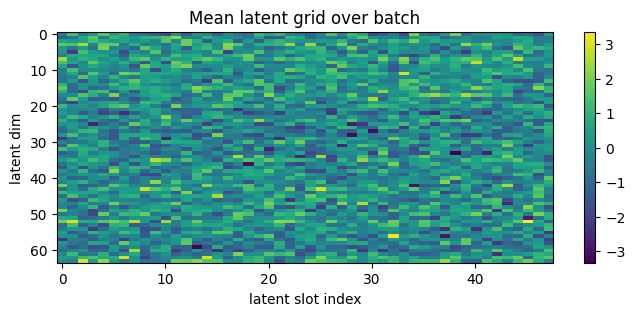

In [7]:
model, _ = load_coper_from_bundle(BUNDLE_1NODE, REPO, device=DEVICE)
loader = tensors_to_loader(
    *load_xy_split(MORTALITY_PICKLE, "val")[:2],
    64,
    32,
    random_state=RANDOM_STATE,
    device=DEVICE,
)
batch = next(iter(loader))
X, tp = batch["X"], batch["tp"]
G = latent_grid(model, X, [tp], [tp], [tp]).cpu().numpy()  # (B, L, D)
fig, ax = plt.subplots(figsize=(8, 3))
im = ax.imshow(G.mean(axis=0).T, aspect="auto", cmap="viridis")
plt.colorbar(im, ax=ax)
ax.set_xlabel("latent slot index")
ax.set_ylabel("latent dim")
plt.title("Mean latent grid over batch")
plt.show()